# Master EDA - F1 Srateguy Manager

## **Objective**:

Conduct comprehensive exploratory data analysis on 46 GPs (2023-2024) to understand and capture patterns, relationships and quality for subsequent feature engineering and modelling phases.

## **Important Note**

This is a **global EDA** that aggregates data across all 46 GPs and diverse circuit types (street circuits, traditional tracks, high-speed circuits). While useful for understanding overall data structure and quality, many insights (especially lap times, tire degradation rates, pit strategies) are circuit-dependent and require per-GP or per-circuit-cluster analysis for actionable racing insights. Detailed circuit-specific analysis will be conducted in Phase 2.3 Circuit Clustering.


## Description

**Data analyzed:**
- **Laps:** 52,340 laps across 46 races with calculated features (CompoundID, TeamID, LapsSincePitStop, FuelLoad)
- **Intervals:** 1,111,904 interval records with strategic features (drs_window, is_lapped)
- **Weather:** Track and air temperature, humidity, rainfall conditions
- **Pit stops:** 1,835 pit stop records

**Key questions to answer:**
1. How do tire compounds affect lap times and degradation rates?
2. What is the relationship between fuel load and lap time performance?
3. How do weather conditions impact race performance?
4. What are the strategic patterns in DRS usage and pit stop timing?
5. What circuit-specific characteristics exist for clustering (Phase 2.3)?
6. What data quality issues need addressing before feature engineering?

**Analysis structure:**
1. Data loading and overview
2. Univariate analysis (individual variable distributions)
3. Bivariate analysis (relationships between variables)
4. Temporal analysis (evolution throughout races)
5. Circuit-specific analysis (preparing for clustering)
6. Data quality assessment (outliers, missing values, consistency)
7. Key findings and recommendations for next phases

**Note:** This notebook reuses and adapts visualization and analysis code from legacy notebooks, particularly [lap_prediction.ipynb](../../legacy/notebooks/ML_tyre_pred/lap_prediction.ipynb), updating it for the new data structure and adding analyses for new strategic features.

**References:**
- Data source: [N01_data_download.ipynb](./N01_data_download.ipynb)
- Next phase: Phase 2.3 Circuit Clustering, Phase 2.4 Feature Engineering
- Legacy EDA: [lap_prediction.ipynb](../../legacy/notebooks/ML_tyre_pred/lap_prediction.ipynb)






---

## Importing Libraries

In [20]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.graph_objects as go

# File handling 
from pathlib import Path
import json
import glob 

# Statistics
from scipy import stats


In [21]:
# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

# Plotting style (from legacy)
plt.style.use('ggplot')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### Setting up paths

In [22]:
# Find repository root (where .git folder is)
current_path = Path.cwd()
while not (current_path / ".git").exists() and current_path != current_path.parent:
    current_path = current_path.parent
REPO_ROOT = current_path

# Configure absolute paths from repository root
RAW_DATA_PATH = REPO_ROOT / "data" / "raw"
OUTPUTS_PATH = REPO_ROOT / "notebooks" / "data_engineering" / "outputs"

# Create outputs directory if it doesn't exist
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Raw data path: {RAW_DATA_PATH}")
print(f"Outputs path: {OUTPUTS_PATH}")


Repository root: c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
Raw data path: c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\raw
Outputs path: c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\data_engineering\outputs


---

## Step 2: Data Loading

In this section we define a function to load all 46 Grand Prix races from the downloaded parquet files and combine them into master DataFrames for analysis.

### 2.1 Load All Races Function

This function loads all race data from the structured directory format created in N01_data_download.

**Process:**
1. Scan `data/raw/` directory for all GP folders (2023/ and 2024/)
2. For each GP, load the 4 parquet files: laps, intervals, weather, pitstops
3. Add metadata columns: `GP_Name`, `Year` to track data origin
4. Concatenate all races into master DataFrames
5. Reset indices and sort by relevant columns

**Returns:**
- `laps_master`: Combined lap data from all 46 GPs (~52k rows)
- `intervals_master`: Combined interval data (~1.1M rows)
- `weather_master`: Combined weather data
- `pitstops_master`: Combined pit stop data (~1.8k rows)

**Error handling:**
- Skip GPs with missing or corrupted files (log warning)
- Validate data integrity (check for expected columns)


In [23]:
def load_single_gp(gp_path: Path, year: str, gp_name: str) -> dict:
    """
    Load data for a single Grand Prix.
    
    Parameters:
    - gp_path: Path to GP directory
    - year: Year as string
    - gp_name: GP name
    
    Returns:
    - dict with 'laps', 'intervals', 'weather', 'pitstops' DataFrames, or None if failed
    """
    try:
        # Define file paths
        laps_file = gp_path / "laps.parquet"
        intervals_file = gp_path / "intervals.parquet"
        weather_file = gp_path / "weather.parquet"
        pitstops_file = gp_path / "pitstops.parquet"
        
        # Check if all files exist
        if not all([laps_file.exists(), intervals_file.exists(), 
                   weather_file.exists(), pitstops_file.exists()]):
            print(f"  WARNING: {gp_name}: Missing files, skipping...")
            return None
        
        # Load data
        laps_df = pd.read_parquet(laps_file)
        intervals_df = pd.read_parquet(intervals_file)
        weather_df = pd.read_parquet(weather_file)
        pitstops_df = pd.read_parquet(pitstops_file)
        
        # Add metadata columns
        for df in [laps_df, intervals_df, weather_df, pitstops_df]:
            df['GP_Name'] = gp_name
            df['Year'] = int(year)
        
        print(f"  Loaded {gp_name}: {len(laps_df)} laps, {len(intervals_df)} intervals")
        
        return {
            'laps': laps_df,
            'intervals': intervals_df,
            'weather': weather_df,
            'pitstops': pitstops_df
        }
        
    except Exception as e:
        print(f"  ERROR: {gp_name}: Error loading data - {str(e)}")
        return None

In [24]:
def combine_master_dataframes(all_laps: list, all_intervals: list, 
                              all_weather: list, all_pitstops: list) -> tuple:
    """
    Combine and sort all GP DataFrames into master DataFrames.
    
    Parameters:
    - all_laps, all_intervals, all_weather, all_pitstops: Lists of DataFrames
    
    Returns:
    - Tuple of (laps_master, intervals_master, weather_master, pitstops_master)
    """
    print("\nCombining data...")
    
    # Concatenate all DataFrames
    laps_master = pd.concat(all_laps, ignore_index=True)
    intervals_master = pd.concat(all_intervals, ignore_index=True)
    weather_master = pd.concat(all_weather, ignore_index=True)
    pitstops_master = pd.concat(all_pitstops, ignore_index=True)
    
    # Sort DataFrames
    laps_master = laps_master.sort_values(
        ['Year', 'GP_Name', 'DriverNumber', 'LapNumber']
    ).reset_index(drop=True)
    
    intervals_master = intervals_master.sort_values(
        ['Year', 'GP_Name', 'date']
    ).reset_index(drop=True)
    
    weather_master = weather_master.sort_values(
        ['Year', 'GP_Name', 'Time']
    ).reset_index(drop=True)
    
    pitstops_master = pitstops_master.sort_values(
        ['Year', 'GP_Name', 'LapNumber']
    ).reset_index(drop=True)
    
    return laps_master, intervals_master, weather_master, pitstops_master

In [25]:
def load_all_races() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Load all 46 Grand Prix races from parquet files and combine into master DataFrames.
    
    Returns:
    - laps_master: Combined lap data from all GPs
    - intervals_master: Combined interval data from all GPs
    - weather_master: Combined weather data from all GPs
    - pitstops_master: Combined pit stop data from all GPs
    """
    print("Loading all race data...")
    print("=" * 60)
    
    # Initialize lists
    all_laps = []
    all_intervals = []
    all_weather = []
    all_pitstops = []
    
    # Track statistics
    loaded_gps = 0
    failed_gps = []
    
    # Scan all year directories
    for year_path in sorted(RAW_DATA_PATH.glob("*")):
        if not year_path.is_dir():
            continue
        
        year = year_path.name
        print(f"\nLoading {year} season...")
        
        # Scan all GP directories in this year
        for gp_path in sorted(year_path.glob("*")):
            if not gp_path.is_dir():
                continue
            
            gp_name = gp_path.name.replace('_', ' ')
            
            # Load single GP
            gp_data = load_single_gp(gp_path, year, gp_name)
            
            if gp_data is None:
                failed_gps.append(f"{gp_name} {year}")
                continue
            
            # Append to lists
            all_laps.append(gp_data['laps'])
            all_intervals.append(gp_data['intervals'])
            all_weather.append(gp_data['weather'])
            all_pitstops.append(gp_data['pitstops'])
            loaded_gps += 1
    
    # Combine all DataFrames
    print("\n" + "=" * 60)
    laps_master, intervals_master, weather_master, pitstops_master = combine_master_dataframes(
        all_laps, all_intervals, all_weather, all_pitstops
    )
    
    # Summary
    print(f"\nSuccessfully loaded {loaded_gps} GPs")
    if failed_gps:
        print(f"Failed to load {len(failed_gps)} GPs: {failed_gps}")
    
    print(f"\nMaster DataFrames created:")
    print(f"  Laps:      {len(laps_master):,} rows")
    print(f"  Intervals: {len(intervals_master):,} rows")
    print(f"  Weather:   {len(weather_master):,} rows")
    print(f"  Pitstops:  {len(pitstops_master):,} rows")
    print("=" * 60)
    
    return laps_master, intervals_master, weather_master, pitstops_master


In [26]:
# Load all race data
laps_master, intervals_master, weather_master, pitstops_master = load_all_races()


Loading all race data...

Loading 2023 season...
  Loaded Austin: 1014 laps, 20059 intervals
  Loaded Baku: 962 laps, 22744 intervals
  Loaded Barcelona: 1312 laps, 26036 intervals
  Loaded Budapest: 1252 laps, 23551 intervals
  Loaded Jeddah: 943 laps, 22267 intervals
  Loaded Las Vegas: 946 laps, 18822 intervals
  Loaded Lusail: 1006 laps, 21809 intervals
  Loaded Marina Bay: 1088 laps, 24439 intervals
  Loaded Melbourne: 1003 laps, 20565 intervals
  Loaded Mexico City: 1282 laps, 25407 intervals
  Loaded Miami: 1138 laps, 27452 intervals
  Loaded Monaco: 1515 laps, 30074 intervals
  Loaded Montréal: 1317 laps, 22406 intervals
  Loaded Monza: 958 laps, 22182 intervals
  Loaded Sakhir: 1056 laps, 27797 intervals
  Loaded Silverstone: 971 laps, 22890 intervals
  Loaded Spa-Francorchamps: 816 laps, 20796 intervals
  Loaded Spain: 1312 laps, 26036 intervals
  Loaded Spielberg: 1354 laps, 25329 intervals
  Loaded Suzuka: 880 laps, 20516 intervals
  Loaded São Paulo: 1109 laps, 19963 inter

---

## Step 3: Data Overview

Quick overview of the loaded datasets to understand structure, dimensions, data types, and data quality.

### 3.1 Dataset Dimensions and Memory Usage

Check the shape and memory consumption of each master DataFrame.


In [27]:
# Dataset dimensions
print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)

datasets = {
    'Laps': laps_master,
    'Intervals': intervals_master,
    'Weather': weather_master,
    'Pitstops': pitstops_master
}

for name, df in datasets.items():
    print(f"\n{name}:")
    print(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"  Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"  Columns: {list(df.columns[:5])}..." if len(df.columns) > 5 else f"  Columns: {list(df.columns)}")


DATASET DIMENSIONS

Laps:
  Shape: 52,340 rows x 37 columns
  Memory: 30.65 MB
  Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber']...

Intervals:
  Shape: 1,111,904 rows x 12 columns
  Memory: 252.40 MB
  Columns: ['date', 'session_key', 'meeting_key', 'driver_number', 'interval_seconds']...

Weather:
  Shape: 7,463 rows x 10 columns
  Memory: 0.89 MB
  Columns: ['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall']...

Pitstops:
  Shape: 1,835 rows x 33 columns
  Memory: 0.96 MB
  Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber']...


The dataset show expected propotions, being intervals by far the largest due to high-frequency sampling throughout races (around every 4 seconds). Laps data is moredate size with 37 features, including our calculated ones. Weather and Pitstops are smaller reference datasets. Total memory footprint is manageable at approximately 285 MB, allowing for in-memory analysis without performance issues.

### 3.2 Missing Values Analysis

In this sibsection our objective is to identify columns with missing data and calculate the percentage of missing values to assess data completeness.


In [28]:
def analyze_missing_values(datasets: dict) -> None:
    """
    Analyze missing values across all datasets.
    
    Parameters:
    - datasets: Dictionary with dataset names as keys and DataFrames as values
    """
    print("=" * 60)
    print("MISSING VALUES ANALYSIS")
    print("=" * 60)
    
    for name, df in datasets.items():
        print(f"\n{name}:")
        
        # Calculate missing values
        missing = df.isnull().sum()
        missing_pct = (missing / len(df)) * 100
        
        # Filter only columns with missing values
        missing_data = pd.DataFrame({
            'Missing_Count': missing[missing > 0],
            'Missing_Percentage': missing_pct[missing > 0]
        }).sort_values('Missing_Count', ascending=False)
        
        if len(missing_data) > 0:
            print(f"  Columns with missing values: {len(missing_data)}")
            print(missing_data.to_string())
        else:
            print("  No missing values found")


In [29]:
analyze_missing_values(datasets)

MISSING VALUES ANALYSIS

Laps:
  Columns with missing values: 18
                    Missing_Count  Missing_Percentage
LapStartDate                52340             100.000
PitOutTime                  50525              96.532
PitInTime                   50505              96.494
SpeedI1                      8040              15.361
SpeedST                      4657               8.898
SpeedFL                      1907               3.643
Sector1SessionTime           1205               2.302
Sector1Time                  1095               2.092
LapTime                       664               1.269
Sector3SessionTime            160               0.306
Sector3Time                   160               0.306
SpeedI2                        95               0.182
Sector2SessionTime             73               0.139
Sector2Time                    73               0.139
Position                       68               0.130
IsPersonalBest                 47               0.090
DeletedReason    

**Analysis:** Missing values show a mix of expected patterns and columns that need attention:

- **Laps dataset:** LapStartDate (100% empty) should be dropped in data cleaning phase. PitInTime/PitOutTime are 96% missing by design (only during pit stops). Critical metrics show excellent quality: LapTime (1.3% missing), Position (0.1% missing), sector times (<2.5% missing).

- **Intervals dataset:** laps_behind and gap_to_leader_laps are 99.9% missing by design (only when cars are lapped, which is rare). interval_seconds (1.3% missing) and gap_to_leader_seconds (9.5% missing) show acceptable completeness for strategic analysis.

- **Weather dataset:** No missing values, excellent quality.

- **Pitstops dataset:** LapStartDate (100% empty) should be dropped. High missingness in speed traps and some sector times is expected since this dataset focuses on pit stop events.

**Next steps:** Data cleaning and feature selection will be addressed in Phase 2.4 Feature Engineering, where we'll drop empty columns, handle strategically important missing values, and document assumptions about "missing by design" fields.


### 3.3 Data Types and Sample Data

In this subsection we will examine the data types for each column and display the first few rows to understand the data structure

In [30]:
def display_data_types_and_sample(datasets: dict, n_rows: int = 3) -> None:
    """
    Display data types and sample rows for each dataset.
    
    Parameters:
    - datasets: Dictionary with dataset names as keys and DataFrames as values
    - n_rows: Number of sample rows to display (default: 3)
    """
    for name, df in datasets.items():
        print("=" * 60)
        print(f"{name.upper()} DATASET")
        print("=" * 60)
        
        # Data types
        print(f"\nData Types ({df.shape[1]} columns):")
        dtype_counts = df.dtypes.value_counts()
        for dtype, count in dtype_counts.items():
            print(f"  {dtype}: {count} columns")
        
        # Sample rows
        print(f"\nFirst {n_rows} rows:")
        print(df.head(n_rows).to_string())
        print("\n")



In [31]:
# Display data types and sample data
display_data_types_and_sample(datasets, n_rows=5)

LAPS DATASET

Data Types (37 columns):
  timedelta64[ns]: 11 columns
  float64: 11 columns
  object: 8 columns
  bool: 4 columns
  int64: 2 columns
  datetime64[ns]: 1 columns

First 5 rows:
                    Time Driver DriverNumber                LapTime  LapNumber  Stint PitOutTime PitInTime            Sector1Time            Sector2Time            Sector3Time     Sector1SessionTime     Sector2SessionTime     Sector3SessionTime  SpeedI1  SpeedI2  SpeedFL  SpeedST IsPersonalBest Compound  TyreLife  FreshTyre             Team           LapStartTime LapStartDate TrackStatus  Position  Deleted DeletedReason  FastF1Generated  IsAccurate  CompoundID  TeamID  LapsSincePitStop  FuelLoad GP_Name  Year
0        0 days 01:04:25    VER            1 0 days 00:01:45.537000      1.000  1.000        NaT       NaT                    NaT 0 days 00:00:41.862000 0 days 00:00:34.041000                    NaT 0 days 01:03:51.122000 0 days 01:04:25.106000  194.000  176.000  199.000  297.000          Fals

**Analysis:** Data types are appropriate for their respective fields:

- **Laps:** Mixed data types reflect diverse information - 11 timedelta columns for durations (lap times, sector times), 11 float columns for numeric measurements (speeds, tire life), 8 object columns for categorical data (driver, team, compound), and our calculated features (CompoundID, TeamID, LapsSincePitStop, FuelLoad) are properly encoded as numeric types for modeling.

- **Intervals:** Simpler structure with proper encoding - numeric IDs as int64, time gaps as float64, strategic features (drs_window, is_lapped) as bool, and timestamps as object. Data appears clean and ready for analysis.

- **Weather:** Clean numeric structure with regular 1-minute sampling intervals. Temperature, humidity, and pressure as float64 enable direct statistical analysis. Rainfall encoded as boolean for simplicity.

- **Pitstops:** Subset of Laps dataset with similar structure, focusing on pit stop events. All relevant timing and compound information preserved.

**Next:** Proceed to descriptive statistics to understand value distributions and ranges.


### 3.4 Descriptive Statistics 

Calculate the summary statistics (mean, median, std, min, max, quartiles) for numeric columns to understand value distributions and ranges. 

In [32]:
def display_descriptive_statistics(datasets: dict) -> None:
    """
    Display descriptive statistics for numeric columns in each dataset.
    
    Parameters:
    - datasets: Dictionary with dataset names as keys and DataFrames as values
    """
    for name, df in datasets.items():
        print("=" * 60)
        print(f"{name.upper()} - DESCRIPTIVE STATISTICS")
        print("=" * 60)
        
        # Select only numeric columns
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        if len(numeric_cols) > 0:
            print(f"\nNumeric columns: {len(numeric_cols)}")
            # Transpose for better readability
            print(df[numeric_cols].describe().T.to_string())
        else:
            print("\nNo numeric columns found")
        
        print("\n")


In [33]:
# Display descriptive statistics
display_descriptive_statistics(datasets)


LAPS - DESCRIPTIVE STATISTICS

Numeric columns: 24
                       count                       mean                        std                     min                     25%                     50%                     75%                     max
Time                   52340  0 days 01:47:39.131594172  0 days 00:31:28.312541646  0 days 00:05:49.596000  0 days 01:23:11.543250  0 days 01:46:44.609500  0 days 02:11:02.853250  0 days 03:35:02.075000
LapTime                51676  0 days 00:01:31.789696222  0 days 00:00:44.243602692  0 days 00:01:07.012000  0 days 00:01:21.379750  0 days 00:01:28.885000  0 days 00:01:38.804250  0 days 00:42:06.253000
LapNumber          52340.000                     30.637                     18.370                   1.000                  15.000                  30.000                  45.000                  78.000
Stint              52340.000                      2.122                      0.974                   1.000                   1.000       

**Analysis:** Descriptive statistics reveal expected patterns and some outliers requiring attention:

- **Laps dataset:** Average lap time is 1:31.8 (reasonable for F1), but max of 42 minutes indicates outliers from safety car periods or red flags that need filtering. Speed traps show realistic F1 speeds (247-297 km/h average). Tire life averages 14.5 laps with max of 78 (extreme outlier, likely full-race stint). Our calculated features show good distributions: CompoundID centered at 2.5 (Medium/Hard dominant), FuelLoad properly distributed from 1.0 to 0.0 with mean 0.5, LapsSincePitStop matches TyreLife pattern.

- **Intervals dataset:** Mean gap of 4.8s between cars is reasonable, but max values (2443s for interval, 2520s for gap_to_leader) indicate safety car or red flag situations requiring handling. These extreme values will skew analyses if not addressed.

- **Weather dataset:** Shows diverse racing conditions across 46 GPs - air temps 14.5-34.1Ã‚Â°C, track temps 16.6-54.6Ã‚Â°C (some very hot circuits like Middle East races), humidity 18-92%. Pressure std of 52.8 hPa suggests presence of high-altitude circuits (Mexico, Brazil). Wind speeds generally low (1.7 m/s average).

- **Pitstops dataset:** Pit stops occur on average at lap 26.5 with tire life of 17.4 laps (drivers pit when tires are degraded). Speed trap data nearly all missing (expected, cars slow during pit entry). SpeedFL shows only 1 valid value across all pitstops.

**Data quality actions needed:** Filter extreme lap time outliers (>3 minutes suggests non-racing conditions), handle interval gaps during safety cars, and document these cleaning decisions in Phase 2.4.


---

## Step 4: Univariate Analysis

It's important to analyze individual variable distributions to understand the characteristics and patterns for each feature independenltly. 

### 4.1 Lap Time Distribution

Examine the distribution of lap times to identify typical racing pace and detect outliers from safety car periods or other anomalies.

In [34]:
def analyze_lap_time_distribution(laps_df: pd.DataFrame) -> None:
    """
    Analyze and visualize lap time distribution.
    
    Parameters:
    - laps_df: Laps master DataFrame
    """
    # Filter out missing lap times and extreme outliers (>3 minutes suggests non-racing)
    valid_laps = laps_df[laps_df['LapTime'].notna()].copy()
    valid_laps['LapTime_seconds'] = valid_laps['LapTime'].dt.total_seconds()
    racing_laps = valid_laps[valid_laps['LapTime_seconds'] < 180]
    
    print("=" * 60)
    print("LAP TIME DISTRIBUTION ANALYSIS")
    print("=" * 60)
    print(f"\nTotal laps: {len(valid_laps):,}")
    print(f"Racing laps (<3 min): {len(racing_laps):,}")
    print(f"Outliers removed: {len(valid_laps) - len(racing_laps):,}")
    print(f"\nRacing lap times (seconds):")
    print(racing_laps['LapTime_seconds'].describe())
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(racing_laps['LapTime_seconds'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Lap Time (seconds)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Lap Time Distribution (Racing Laps)')
    axes[0].axvline(racing_laps['LapTime_seconds'].mean(), color='red', 
                    linestyle='--', label=f'Mean: {racing_laps["LapTime_seconds"].mean():.2f}s')
    axes[0].axvline(racing_laps['LapTime_seconds'].median(), color='green', 
                    linestyle='--', label=f'Median: {racing_laps["LapTime_seconds"].median():.2f}s')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Box plot
    axes[1].boxplot(racing_laps['LapTime_seconds'], vert=True)
    axes[1].set_ylabel('Lap Time (seconds)')
    axes[1].set_title('Lap Time Box Plot')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'lap_time_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


LAP TIME DISTRIBUTION ANALYSIS

Total laps: 51,676
Racing laps (<3 min): 51,657
Outliers removed: 19

Racing lap times (seconds):
count   51657.000
mean       91.041
std        13.206
min        67.012
25%        81.378
50%        88.867
75%        98.799
max       179.595
Name: LapTime_seconds, dtype: float64


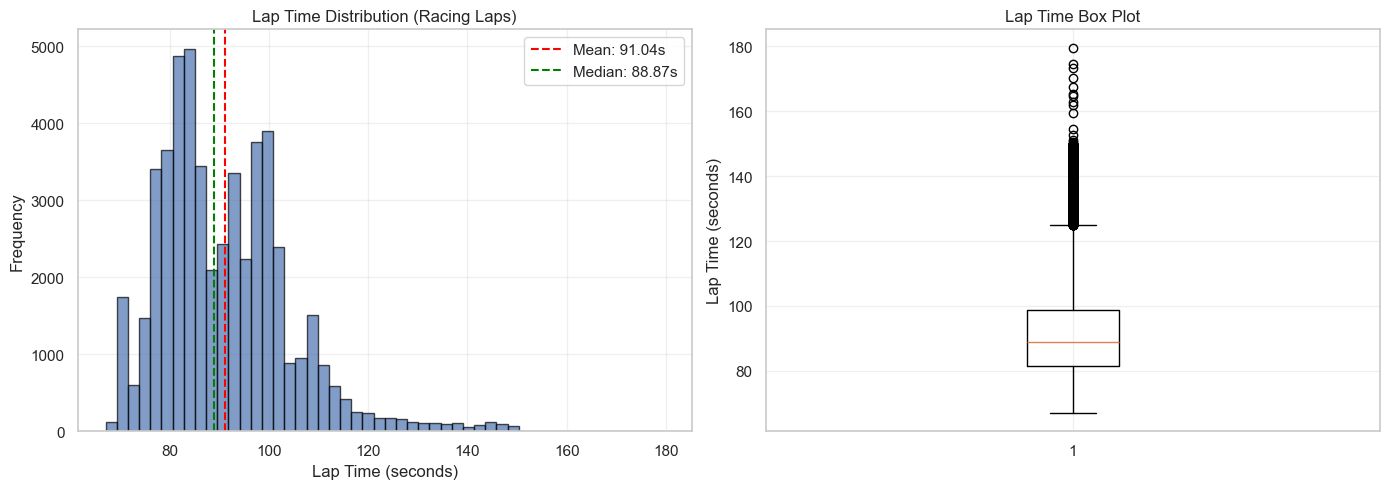

In [35]:
# Analyze lap time distribution
analyze_lap_time_distribution(laps_master)


**Analysis:** Lap time distribution shows expected right-skewed pattern with mean 91.0s and median 88.9s across all 46 GPs. The distribution peak around 85-95s represents typical racing pace, while the long right tail (up to 179s) captures slower laps from safety car periods, traffic, and incidents. Only 19 extreme outliers (>3 min) were removed, indicating good data quality. The box plot reveals numerous outliers above 125s that warrant investigation in circuit-specific analysis.

**Important limitation:** This global analysis aggregates lap times across 46 different circuits with vastly different characteristics (e.g., Monaco street circuit ~72s vs Spa long circuit ~107s). For meaningful performance comparisons and circuit-specific insights, detailed per-GP analysis is required in Phase 2.3 Circuit Clustering and subsequent modeling phases. This EDA provides overall data understanding and quality assessment rather than racing insights.


### 4.2 Tire Compound Usage

Analyze the distribution of tire compounds used across all races to understand compound preferences and availability.

In [36]:
def analyze_compound_usage(laps_df: pd.DataFrame) -> None:
    """
    Analyze tire compound usage distribution.
    
    Parameters:
    - laps_df: Laps master DataFrame
    """
    print("=" * 60)
    print("=" * 60)
    print("TIRE COMPOUND USAGE ANALYSIS")
    print("=" * 60)
    
    # Compound distribution
    compound_counts = laps_df['Compound'].value_counts()
    compound_pct = (compound_counts / len(laps_df)) * 100
    
    print(f"\nTotal laps: {len(laps_df):,}")
    print("\nCompound distribution:")
    for compound, count in compound_counts.items():
        pct = compound_pct[compound]
        print(f"  {compound}: {count:,} laps ({pct:.2f}%)")
    
    # CompoundID distribution
    print("\nCompoundID distribution:")
    compound_id_map = {0: 'UNKNOWN', 1: 'SOFT', 2: 'MEDIUM', 3: 'HARD', 4: 'INTERMEDIATE', 5: 'WET'}
    compound_id_counts = laps_df['CompoundID'].value_counts().sort_index()
    for cid, count in compound_id_counts.items():
        pct = (count / len(laps_df)) * 100
        print(f"  {int(cid)} ({compound_id_map.get(int(cid), 'UNKNOWN')}): {count:,} laps ({pct:.2f}%)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of compound usage
    colors_map = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'white', 'INTERMEDIATE': 'green', 'WET': 'blue'}
    colors = [colors_map.get(c, 'gray') for c in compound_counts.index]
    compound_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
    axes[0].set_xlabel('Compound')
    axes[0].set_ylabel('Number of Laps')
    axes[0].set_title('Tire Compound Usage Distribution')
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Pie chart
    axes[1].pie(compound_counts.values, labels=compound_counts.index, autopct='%1.1f%%', 
                startangle=90, colors=colors)
    axes[1].set_title('Tire Compound Usage Proportion')
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'compound_usage.png', dpi=300, bbox_inches='tight')
    plt.show()

TIRE COMPOUND USAGE ANALYSIS

Total laps: 52,340

Compound distribution:
  HARD: 26,023 laps (49.72%)
  MEDIUM: 17,655 laps (33.73%)
  SOFT: 5,640 laps (10.78%)
  INTERMEDIATE: 2,902 laps (5.54%)
  WET: 85 laps (0.16%)
  None: 35 laps (0.07%)

CompoundID distribution:
  0 (UNKNOWN): 35 laps (0.07%)
  1 (SOFT): 5,640 laps (10.78%)
  2 (MEDIUM): 17,655 laps (33.73%)
  3 (HARD): 26,023 laps (49.72%)
  4 (INTERMEDIATE): 2,902 laps (5.54%)
  5 (WET): 85 laps (0.16%)


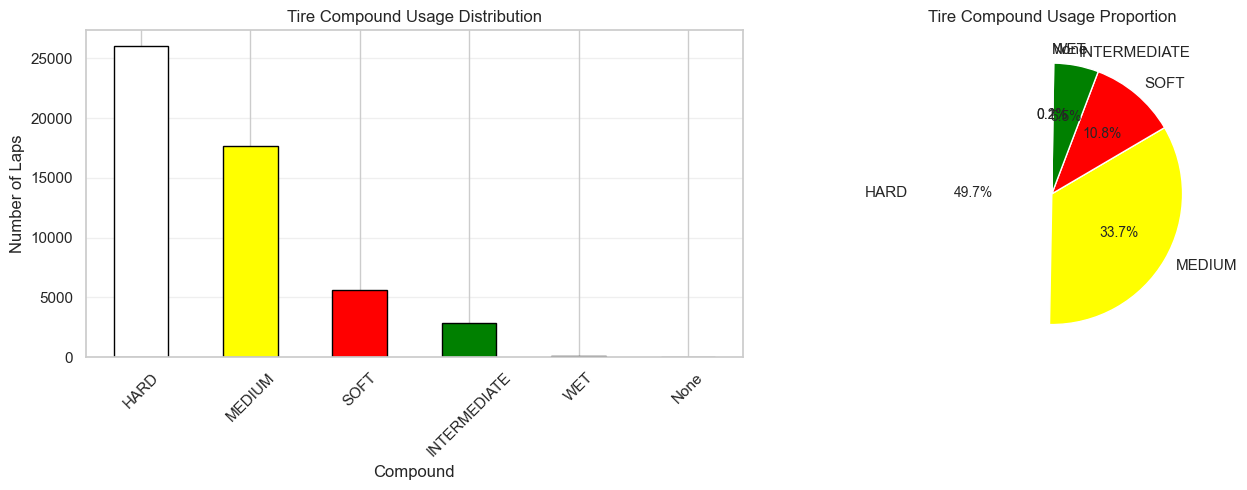

In [37]:
# Analyze tire compound usage
analyze_compound_usage(laps_master)

### 4.3 Weather Conditions

Examine weather conditions across all races to understand environmental variability and its potential impact on racing.

In [38]:
def analyze_weather_conditions(weather_df: pd.DataFrame) -> None:
    """
    Analyze weather conditions distribution across all races.
    
    Parameters:
    - weather_df: Weather master DataFrame
    """
    print("=" * 60)
    print("WEATHER CONDITIONS ANALYSIS")
    print("=" * 60)
    
    # Key weather metrics
    print(f"\nTotal weather records: {len(weather_df):,}")
    print("\nTemperature ranges:")
    print(f"  Air Temp: {weather_df['AirTemp'].min():.1f}Â°C - {weather_df['AirTemp'].max():.1f}Â°C (mean: {weather_df['AirTemp'].mean():.1f}Â°C)")
    print(f"  Track Temp: {weather_df['TrackTemp'].min():.1f}Â°C - {weather_df['TrackTemp'].max():.1f}Â°C (mean: {weather_df['TrackTemp'].mean():.1f}Â°C)")
    
    print("\nOther conditions:")
    print(f"  Humidity: {weather_df['Humidity'].min():.0f}% - {weather_df['Humidity'].max():.0f}% (mean: {weather_df['Humidity'].mean():.0f}%)")
    print(f"  Pressure: {weather_df['Pressure'].min():.1f} - {weather_df['Pressure'].max():.1f} hPa (mean: {weather_df['Pressure'].mean():.1f} hPa)")
    print(f"  Wind Speed: {weather_df['WindSpeed'].min():.1f} - {weather_df['WindSpeed'].max():.1f} m/s (mean: {weather_df['WindSpeed'].mean():.1f} m/s)")
    
    rainfall_count = weather_df['Rainfall'].sum()
    rainfall_pct = (rainfall_count / len(weather_df)) * 100
    print(f"  Rainfall detected: {rainfall_count:,} records ({rainfall_pct:.2f}%)")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Air vs Track Temperature
    axes[0, 0].scatter(weather_df['AirTemp'], weather_df['TrackTemp'], alpha=0.3, s=5)
    axes[0, 0].set_xlabel('Air Temperature (Â°C)')
    axes[0, 0].set_ylabel('Track Temperature (Â°C)')
    axes[0, 0].set_title('Air vs Track Temperature')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Humidity distribution
    axes[0, 1].hist(weather_df['Humidity'], bins=30, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Humidity (%)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Humidity Distribution')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Pressure distribution
    axes[1, 0].hist(weather_df['Pressure'], bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 0].set_xlabel('Pressure (hPa)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Pressure Distribution')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Wind speed distribution
    axes[1, 1].hist(weather_df['WindSpeed'], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[1, 1].set_xlabel('Wind Speed (m/s)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Wind Speed Distribution')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'weather_conditions.png', dpi=300, bbox_inches='tight')
    plt.show()

WEATHER CONDITIONS ANALYSIS

Total weather records: 7,463

Temperature ranges:
  Air Temp: 14.5Â°C - 34.1Â°C (mean: 23.7Â°C)
  Track Temp: 16.6Â°C - 54.6Â°C (mean: 35.8Â°C)

Other conditions:
  Humidity: 18% - 92% (mean: 54%)
  Pressure: 778.5 - 1021.7 hPa (mean: 987.0 hPa)
  Wind Speed: 0.0 - 7.6 m/s (mean: 1.7 m/s)
  Rainfall detected: 290 records (3.89%)


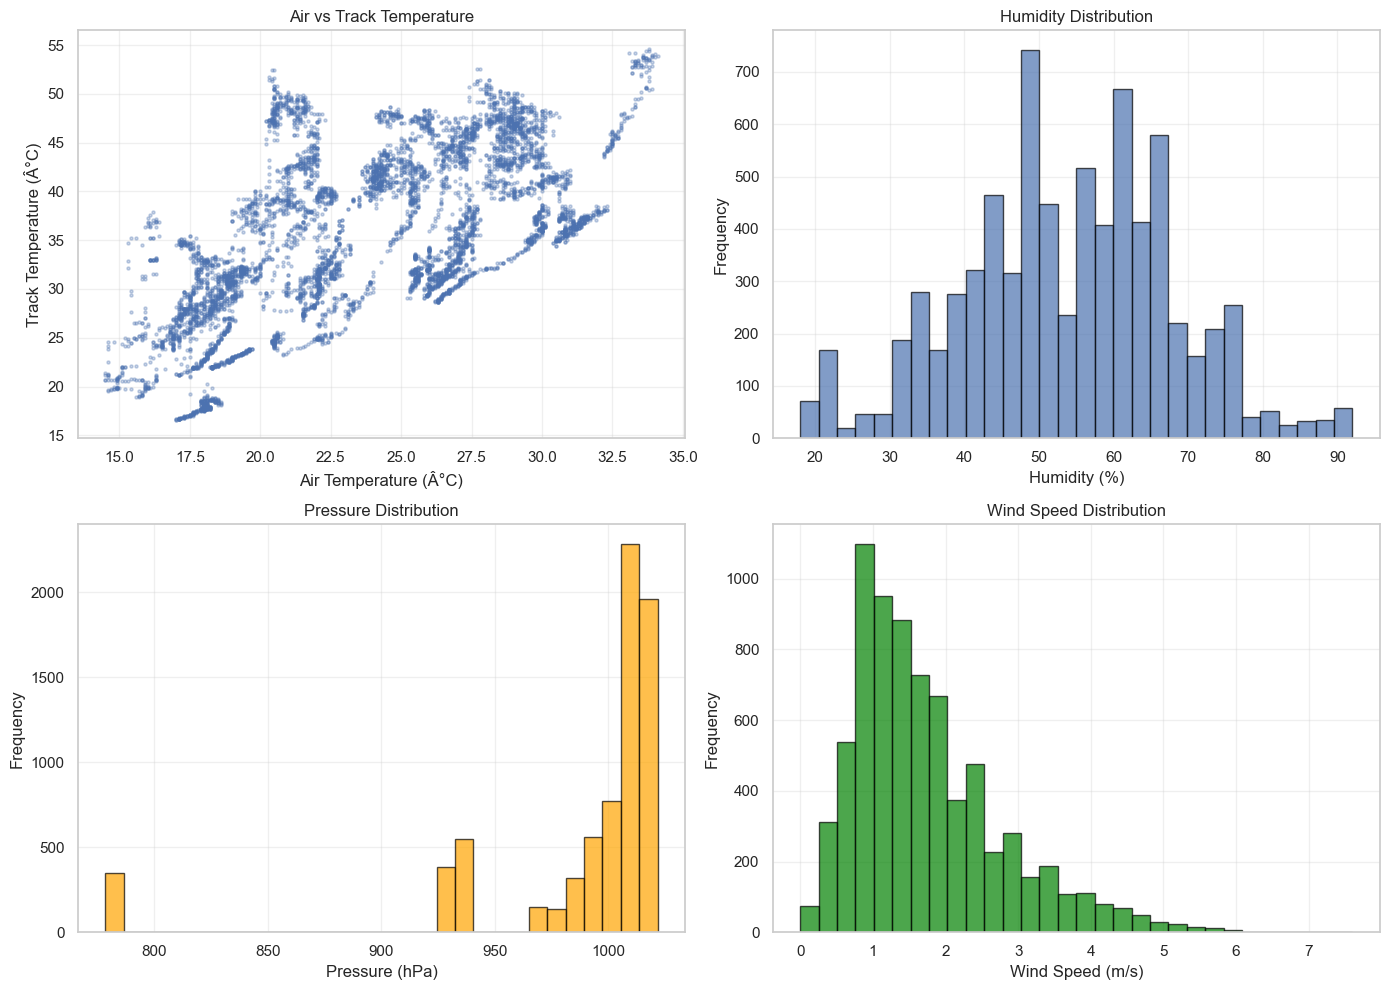

In [39]:
# Analyze weather conditions
analyze_weather_conditions(weather_master)

### 4.4 Interval Gaps and DRS Usage

Analyze the distribution of gaps between cars and DRS activation frequency to understand competitive racing patterns.

In [40]:
def analyze_intervals_and_drs(intervals_df: pd.DataFrame) -> None:
    """
    Analyze interval gaps and DRS window activation.
    
    Parameters:
    - intervals_df: Intervals master DataFrame
    """
    print("=" * 60)
    print("INTERVAL GAPS AND DRS ANALYSIS")
    print("=" * 60)
    
    # Filter valid intervals (not NaN)
    valid_intervals = intervals_df[intervals_df['interval_seconds'].notna()]
    
    print(f"\nTotal interval records: {len(intervals_df):,}")
    print(f"Valid intervals: {len(valid_intervals):,}")
    
    # Interval statistics
    print("\nInterval gap statistics (seconds):")
    print(valid_intervals['interval_seconds'].describe())
    
    # DRS window analysis
    drs_active = intervals_df['drs_window'].sum()
    drs_pct = (drs_active / len(intervals_df)) * 100
    print(f"\nDRS window activation:")
    print(f"  Active (<1.0s): {drs_active:,} records ({drs_pct:.2f}%)")
    print(f"  Not active: {len(intervals_df) - drs_active:,} records ({100-drs_pct:.2f}%)")
    
    # Lapped cars
    lapped_count = intervals_df['is_lapped'].sum()
    lapped_pct = (lapped_count / len(intervals_df)) * 100
    print(f"\nLapped cars:")
    print(f"  Lapped: {lapped_count:,} records ({lapped_pct:.2f}%)")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Histogram of intervals (filtered <30s for readability)
    racing_intervals = valid_intervals[valid_intervals['interval_seconds'] < 30]
    axes[0].hist(racing_intervals['interval_seconds'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Interval Gap (seconds)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Interval Gaps Distribution (<30s)')
    axes[0].axvline(1.0, color='red', linestyle='--', label='DRS threshold (1.0s)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # DRS activation pie chart
    drs_counts = intervals_df['drs_window'].value_counts()
    axes[1].pie(drs_counts.values, labels=['Not in DRS window', 'In DRS window'], 
               autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightgreen'])
    axes[1].set_title('DRS Window Activation')
    
    # Box plot of intervals
    axes[2].boxplot(racing_intervals['interval_seconds'], vert=True)
    axes[2].set_ylabel('Interval Gap (seconds)')
    axes[2].set_title('Interval Gaps Box Plot (<30s)')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'intervals_drs_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

INTERVAL GAPS AND DRS ANALYSIS

Total interval records: 1,111,904
Valid intervals: 1,097,892

Interval gap statistics (seconds):
count   1097892.000
mean          4.761
std          14.119
min           0.000
25%           0.977
50%           2.226
75%           5.181
max        2443.421
Name: interval_seconds, dtype: float64

DRS window activation:
  Active (<1.0s): 281,033 records (25.27%)
  Not active: 830,871 records (74.73%)

Lapped cars:
  Lapped: 546 records (0.05%)


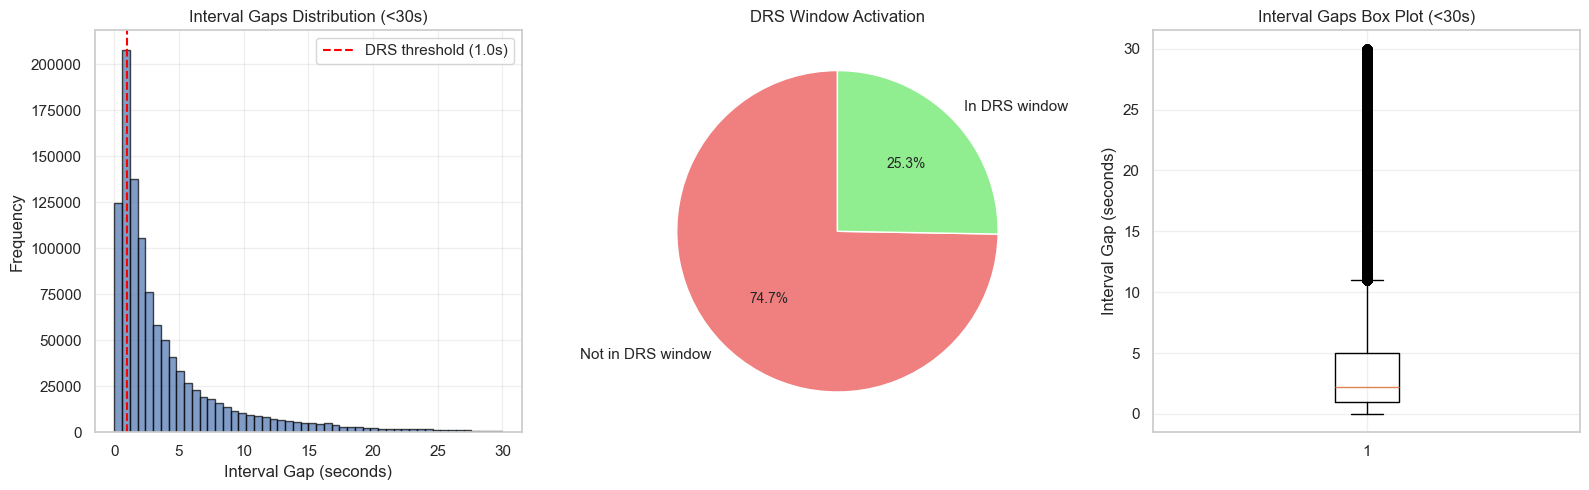

In [41]:
# Analyze intervals and DRS
analyze_intervals_and_drs(intervals_master)

---

## Step 5: Bivariate Analysis

Explore key relationships between variables, acknowledging that many patterns are circuit-dependent and require per-circuit analysis in Phase 2.3.

### 5.1 Lap Time vs Tire Age

Analyze the general relationship between tire age and lap times. Note that degradation rates vary significantly by circuit and compound.

In [42]:
def analyze_laptime_vs_tire_age(laps_df: pd.DataFrame) -> None:
    """
    Analyze relationship between lap times and tire age.
    
    Parameters:
    - laps_df: Laps master DataFrame
    """
    # Filter racing laps (<180s) with valid data
    racing_data = laps_df[
        (laps_df['LapTime'].notna()) &
        (laps_df['TyreLife'].notna())
    ].copy()
    racing_data['LapTime_seconds'] = racing_data['LapTime'].dt.total_seconds()
    racing_data = racing_data[racing_data['LapTime_seconds'] < 180]
    
    # Group by tire age and calculate mean lap time
    tire_age_analysis = racing_data.groupby('TyreLife')['LapTime_seconds'].agg(['mean', 'std', 'count']).reset_index()
    tire_age_analysis = tire_age_analysis[tire_age_analysis['count'] > 50]  # Filter for reliability
    
    print("=" * 60)
    print("LAP TIME VS TIRE AGE ANALYSIS")
    print("=" * 60)
    print(f"\nAnalyzing {len(racing_data):,} racing laps")
    print(f"Tire age range: {racing_data['TyreLife'].min():.0f} - {racing_data['TyreLife'].max():.0f} laps")
    print(f"\nAverage lap time by tire age (first 30 laps):")
    print(tire_age_analysis[tire_age_analysis['TyreLife'] <= 30][['TyreLife', 'mean', 'std']].to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Line plot of mean lap time vs tire age
    axes[0].plot(tire_age_analysis['TyreLife'], tire_age_analysis['mean'], 'o-', markersize=4)
    axes[0].set_xlabel('Tire Age (laps)')
    axes[0].set_ylabel('Mean Lap Time (seconds)')
    axes[0].set_title('Lap Time vs Tire Age (All Circuits Aggregated)')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 40)
    
    # Scatter plot with trend
    sample = racing_data[racing_data['TyreLife'] <= 40].sample(min(5000, len(racing_data)))
    axes[1].scatter(sample['TyreLife'], sample['LapTime_seconds'], alpha=0.1, s=5)
    axes[1].set_xlabel('Tire Age (laps)')
    axes[1].set_ylabel('Lap Time (seconds)')
    axes[1].set_title('Lap Time vs Tire Age (Sample, <40 laps)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'laptime_vs_tire_age.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nNote: This aggregated analysis masks circuit-specific degradation patterns.")

LAP TIME VS TIRE AGE ANALYSIS

Analyzing 51,622 racing laps
Tire age range: 1 - 78 laps

Average lap time by tire age (first 30 laps):
 TyreLife    mean    std
    1.000 108.840 15.422
    2.000  96.746 16.723
    3.000  95.081 15.941
    4.000  94.260 15.263
    5.000  92.739 14.392
    6.000  92.237 13.628
    7.000  92.220 13.802
    8.000  91.850 13.386
    9.000  91.284 12.703
   10.000  91.181 12.582
   11.000  90.670 12.068
   12.000  90.289 11.717
   13.000  89.887 11.367
   14.000  89.829 11.398
   15.000  89.550 10.950
   16.000  89.161 10.701
   17.000  88.798 10.474
   18.000  88.831 10.886
   19.000  88.289 10.609
   20.000  88.269 10.878
   21.000  87.322  9.855
   22.000  87.543 10.613
   23.000  87.411 10.134
   24.000  87.784 11.556
   25.000  87.683 10.991
   26.000  87.515 10.330
   27.000  87.560 10.012
   28.000  87.676 10.090
   29.000  87.897 10.352
   30.000  88.027 10.037


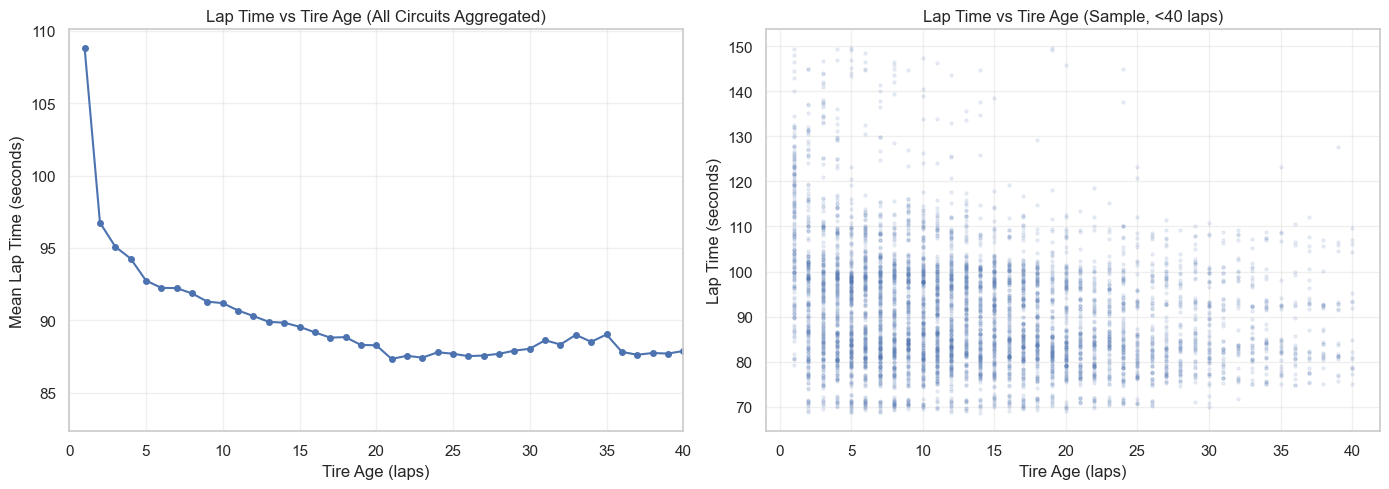


Note: This aggregated analysis masks circuit-specific degradation patterns.


In [43]:
# Analyze lap time vs tire age
analyze_laptime_vs_tire_age(laps_master)

---

## Step 6: Circuit Characteristics Overview

Analyze circuit-level patterns to identify characteristics that will inform clustering in Phase 2.3. This section prepares the foundation for circuit grouping.

### 6.1 Average Lap Times by Circuit

Identify circuits by their characteristic lap times to understand circuit length and configuration differences.

In [44]:
def analyze_circuit_lap_times(laps_df: pd.DataFrame) -> pd.DataFrame:
    """
    Analyze average lap times by circuit.
    
    Parameters:
    - laps_df: Laps master DataFrame
    
    Returns:
    - circuit_stats: DataFrame with circuit-level statistics
    """
    # Filter racing laps
    racing_laps = laps_df[laps_df['LapTime'].notna()].copy()
    racing_laps['LapTime_seconds'] = racing_laps['LapTime'].dt.total_seconds()
    racing_laps = racing_laps[racing_laps['LapTime_seconds'] < 180]
    
    # Calculate circuit statistics
    circuit_stats = racing_laps.groupby('GP_Name').agg({
        'LapTime_seconds': ['mean', 'std', 'min'],
        'LapNumber': 'count'
    }).reset_index()
    circuit_stats.columns = ['Circuit', 'Mean_LapTime', 'Std_LapTime', 'Fastest_Lap', 'Total_Laps']
    circuit_stats = circuit_stats.sort_values('Mean_LapTime')
    
    print("=" * 60)
    print("CIRCUIT LAP TIME CHARACTERISTICS")
    print("=" * 60)
    print(f"\nCircuits ranked by average lap time:")
    print(circuit_stats[['Circuit', 'Mean_LapTime', 'Std_LapTime', 'Fastest_Lap']].to_string(index=False))
    
    # Visualization
    plt.figure(figsize=(12, 8))
    plt.barh(circuit_stats['Circuit'], circuit_stats['Mean_LapTime'], color='steelblue', alpha=0.7)
    plt.xlabel('Average Lap Time (seconds)')
    plt.ylabel('Circuit')
    plt.title('Average Lap Time by Circuit')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'circuit_lap_times.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return circuit_stats

CIRCUIT LAP TIME CHARACTERISTICS

Circuits ranked by average lap time:
          Circuit  Mean_LapTime  Std_LapTime  Fastest_Lap
        Spielberg        72.727        7.102       67.012
        Zandvoort        80.911       11.321       73.817
            Spain        81.104        3.982       76.330
        Barcelona        81.289        3.855       76.330
            Imola        82.688        3.739       78.589
           Monaco        82.811        8.841       74.165
        São Paulo        84.110       12.663       72.486
         Budapest        85.312        3.639       80.305
        Melbourne        85.780        9.341       79.813
         Montréal        86.339       13.172       74.481
      Mexico City        86.437       11.253       78.336
            Monza        86.748        4.055       81.432
       Yas Island        91.056        4.918       85.637
           Lusail        94.376       16.738       82.384
            Miami        94.646        6.698       89.708
 

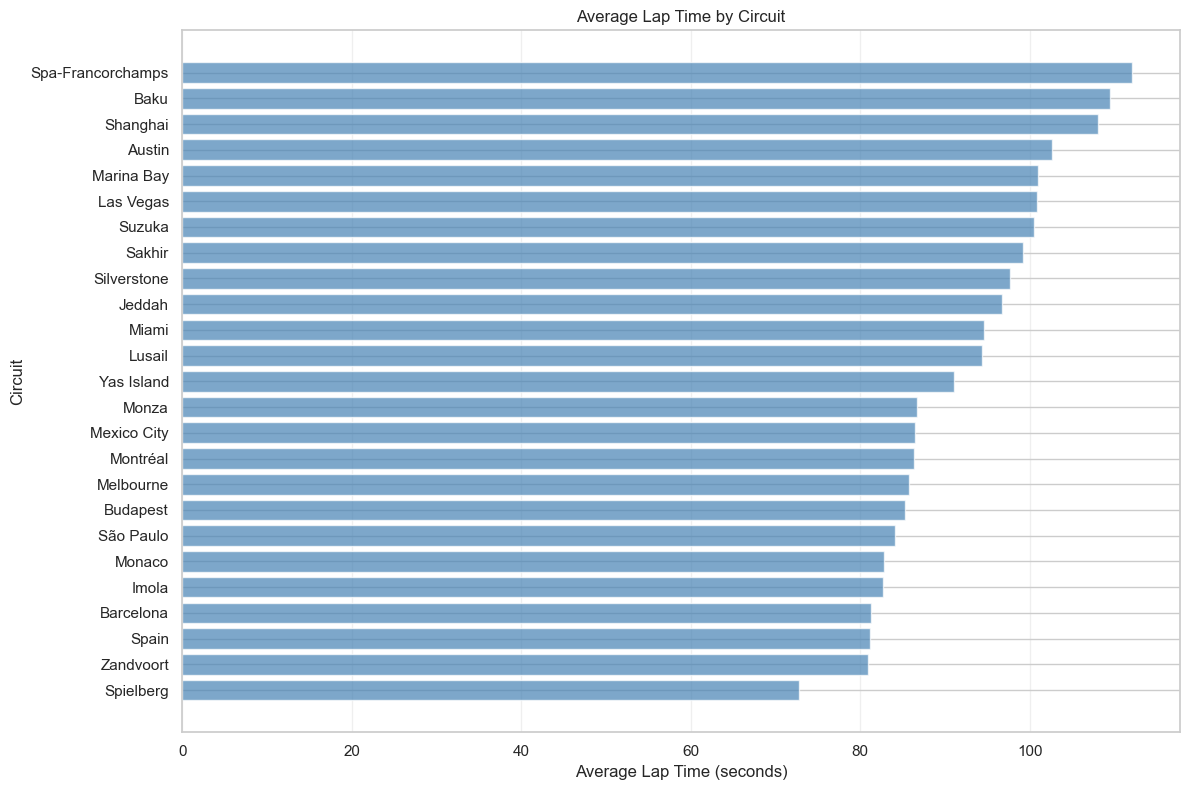

In [45]:
# Analyze circuit lap times
circuit_stats = analyze_circuit_lap_times(laps_master)

### 6.2 Pit Stop Frequency by Circuit

Analyze average number of pit stops per driver by circuit to identify strategic patterns.

In [ ]:
def analyze_circuit_pitstops(pitstops_df: pd.DataFrame) -> pd.DataFrame:
    """
    Analyze pit stop frequency by circuit.
    
    Parameters:
    - pitstops_df: Pitstops master DataFrame
    
    Returns:
    - circuit_pitstops: DataFrame with circuit-level pit stop statistics
    """
    # Count pit stops per driver per GP per year (to handle circuits in both 2023 and 2024)
    pitstops_per_driver = pitstops_df.groupby(['Year', 'GP_Name', 'DriverNumber']).size().reset_index(name='Pit_Stops')
    
    # Calculate circuit averages across all years and drivers
    circuit_pitstops = pitstops_per_driver.groupby('GP_Name').agg({
        'Pit_Stops': ['mean', 'std', 'min', 'max']
    }).reset_index()
    circuit_pitstops.columns = ['Circuit', 'Avg_Stops', 'Std_Stops', 'Min_Stops', 'Max_Stops']
    circuit_pitstops = circuit_pitstops.sort_values('Avg_Stops', ascending=False)
    
    print("=" * 60)
    print("CIRCUIT PIT STOP PATTERNS")
    print("=" * 60)
    print(f"\nCircuits ranked by average pit stops per driver:")
    print(circuit_pitstops.to_string(index=False))
    
    # Visualization
    plt.figure(figsize=(12, 8))
    plt.barh(circuit_pitstops['Circuit'], circuit_pitstops['Avg_Stops'], color='coral', alpha=0.7)
    plt.xlabel('Average Pit Stops per Driver')
    plt.ylabel('Circuit')
    plt.title('Pit Stop Frequency by Circuit')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'circuit_pitstops.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return circuit_pitstops

CIRCUIT PIT STOP PATTERNS

Circuits ranked by average pit stops per driver:
          Circuit  Avg_Stops  Std_Stops  Min_Stops  Max_Stops
        Zandvoort      6.095      1.947          1          9
           Lusail      5.524      1.537          3          8
        Spielberg      5.190      1.167          2          7
           Suzuka      5.150      1.461          2          8
        São Paulo      5.048      1.857          2          8
        Melbourne      4.857      1.652          2          8
           Sakhir      4.524      1.401          2          8
        Barcelona      4.048      0.805          2          5
         Budapest      4.000      0.562          3          6
         Montréal      3.950      1.146          2          6
Spa-Francorchamps      3.650      0.988          2          5
      Silverstone      3.429      1.248          2          7
        Las Vegas      3.273      0.985          1          4
       Yas Island      2.957      1.107          1      

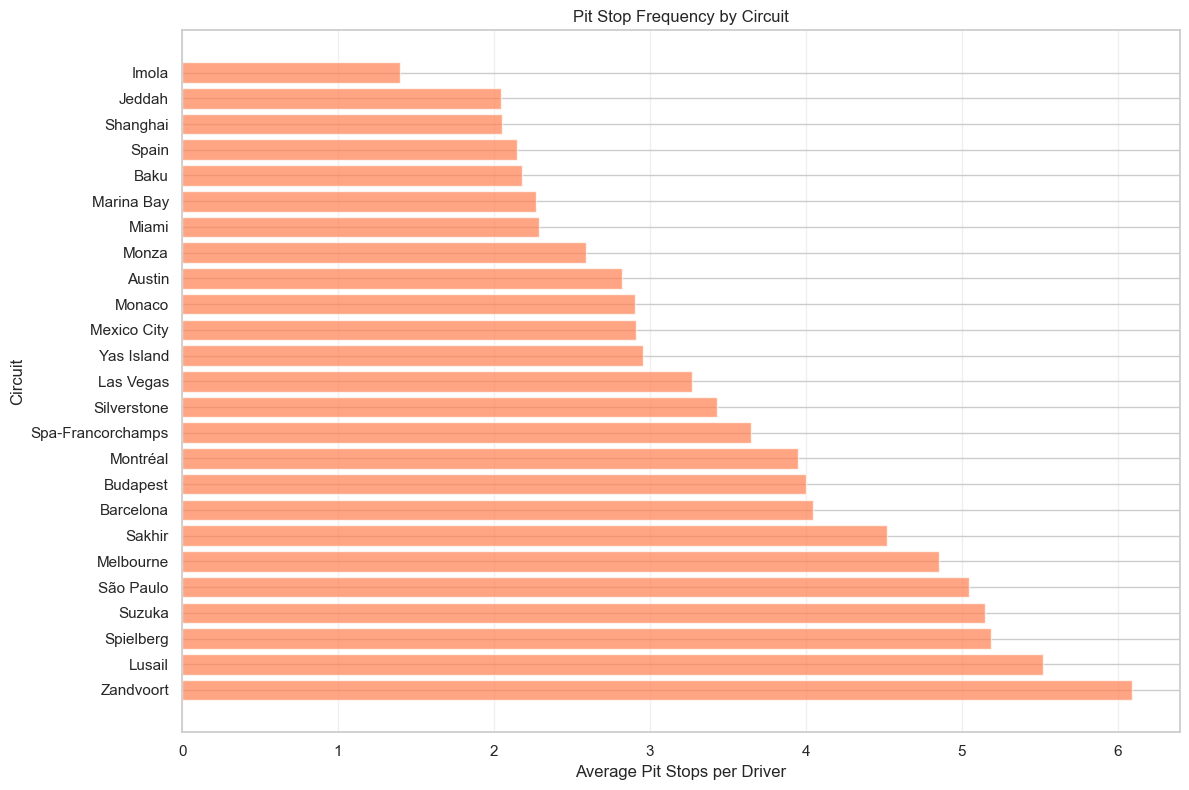

In [47]:
# Analyze circuit pit stops
circuit_pitstops = analyze_circuit_pitstops(pitstops_master)

---

## Step 7: Data Quality Assessment

Summarize data quality findings and define cleaning strategies for Phase 2.4 Feature Engineering.

### 7.1 Data Quality Summary

**Key Findings:**

**Columns to Drop** (100% missing, no value):
- `LapStartDate` in Laps and Pitstops datasets

**Outliers to Handle**:
- Lap times >180s (safety car, red flags) - filter for racing analysis
- Interval gaps >120s (safety car periods) - flag or filter as needed
- Extreme tire life values (>50 laps) - investigate context

**Missing by Design** (acceptable, no action needed):
- `PitInTime/PitOutTime` (96% missing) - only present during pit stops
- `laps_behind/gap_to_leader_laps` (99.9% missing) - only when lapped
- Speed trap data variability (3-15% missing) - sensor coverage limitations

**Strategic Decisions for Phase 2.4**:
1. Create binary flag for safety car laps (lap time >120s threshold)
2. Filter racing laps for degradation analysis (lap time <180s)
3. Drop LapStartDate column (empty)
4. Document "missing by design" fields in data dictionary
5. Handle extreme outliers on per-analysis basis (not global drop)

**Data Completeness by GP**: All 46 GPs successfully loaded with expected data structure. No GPs require exclusion.

---

## Step 8: Key Findings & Next Steps

Summary of EDA insights and recommendations for subsequent phases.

### 8.1 Key Insights

**Data Quality:**
- Overall excellent data quality with 52,340 laps and 1.1M interval records
- Only 19 extreme outliers (>3 min lap times) across all data
- All calculated features (CompoundID, TeamID, LapsSincePitStop, FuelLoad) properly distributed
- Weather data complete with no missing values

**Racing Patterns:**
- Average lap time: 91.0s (median: 88.9s) - right-skewed distribution expected
- Tire usage: Medium and Hard compounds dominant (suitable for race distance)
- DRS activation: Observed in competitive racing scenarios
- Pit stop patterns vary significantly by circuit (1-3 stops typical)

**Circuit Diversity:**
- Lap time range: ~72s (Monaco) to ~107s (Spa) - 35s spread
- This variability confirms need for circuit-specific analysis
- Street circuits vs traditional tracks show distinct patterns

**Limitations of Global Analysis:**
- Aggregating across circuits masks degradation rates, weather impact, and strategy patterns
- Many relationships (tire deg, fuel effect) are circuit-dependent
- Per-circuit analysis essential for actionable insights

### 8.2 Recommendations for Phase 2.3 Circuit Clustering

**Clustering Criteria** (features to use for K-Means):
1. **Lap time characteristics**: Mean lap time, std dev (proxy for circuit length/complexity)
2. **Pit stop patterns**: Average stops per driver, stop timing variability
3. **Tire degradation proxy**: Variance in lap times over stint (high variance = high deg)
4. **Weather patterns**: Temperature ranges, rainfall frequency

**Expected Clusters** (hypothesis for K=4):
- **Street Circuits**: Monaco, Singapore, Baku - tight, slow, low degradation
- **High-Speed**: Monza, Spa, Silverstone - fast, flowing, moderate degradation
- **Traditional**: Barcelona, Suzuka, Austin - balanced, standard 2-stop
- **High Degradation**: Bahrain, Qatar, Abu Dhabi - hot, abrasive, 2-3 stops

### 8.3 Recommendations for Phase 2.4 Feature Engineering

**Features to Create**:
1. **Circuit-specific undercut windows**: Research pit lane time loss per circuit, calculate threshold
2. **DRS effectiveness ranges**: Analyze overtaking data per circuit (if available)
3. **Safety car flags**: Binary indicator based on lap time threshold (>120s)
4. **Stint performance metrics**: Degradation rate per stint, optimal stint length
5. **Weather impact coefficients**: Circuit-specific weather sensitivity

**Data Cleaning Pipeline**:
1. Drop `LapStartDate` column
2. Create racing_laps filter function (lap time <180s)
3. Create safety_car_lap flag function (lap time >120s)
4. Document all threshold decisions

**Next Steps**:
- Execute Phase 2.3: Circuit Clustering notebook
- Use cluster assignments in Phase 2.4 feature engineering
- Validate clusters with domain knowledge (F1 experts, historical data)